# Table des matières 

- `PREP-COMMUNE` : Préparation commune (identique pour A et B) : chargement, typage, suppression identifiants, extraction `spec_*`, nettoyage `MachineHoursCurrentMeter`/`YearMade`, diagnostic NaN structurel
- `FORK` : Copie `df_methodeA` / `df_methodeB`
- `BLOC-A` : Bloc Méthode A (autonome, ne référence que `df_methodeA`)
  - `A-FEATENG` : Feature engineering Méthode A
- `BLOC-B` : Bloc Méthode B (autonome, ne référence que `df_methodeB`)
  - `B-FEATENG` : Feature engineering Méthode B
- `SUITE` : Ce qui reste à faire (hors périmètre de cette réorg)


PRÉPARATION COMMUNE PREP-COMMUNE

Identique pour Méthode A et Méthode B : tout ce qui suit, jusqu'à la copie en deux DataFrames, ne dépend d'aucun choix de méthode.

In [84]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge 
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


df = pd.read_csv("../data/raw/bluebook-for-bulldozers/TrainAndValid.csv", low_memory=False, parse_dates=["saledate"])
df["saledate"] = df["saledate"].sort_values()

In [85]:
import sys
sys.path.append("..")
from src.preprocessing import regrouper_categories_rares, zero_vers_nan, Transformation_binaire, remplacer_au_dessus_seuil, fusionner_categories, extraire_dates, imputation_mediane_a_nan, variable_nan_structurel, imputer_valeurs_rares, nettoyer_hors_bornes

In [86]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 412698 entries, 0 to 412697
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalesID                   412698 non-null  int64         
 1   SalePrice                 412698 non-null  float64       
 2   MachineID                 412698 non-null  int64         
 3   ModelID                   412698 non-null  int64         
 4   datasource                412698 non-null  int64         
 5   auctioneerID              392562 non-null  float64       
 6   YearMade                  412698 non-null  int64         
 7   MachineHoursCurrentMeter  147504 non-null  float64       
 8   UsageBand                 73670 non-null   str           
 9   saledate                  412698 non-null  datetime64[us]
 10  fiModelDesc               412698 non-null  str           
 11  fiBaseModel               412698 non-null  str           
 12  fiSecondaryDe

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,saledate
count,4.126980e+05,412698.000000,4.126980e+05,412698.000000,412698.000000,392562.000000,412698.000000,1.475040e+05,412698
mean,2.011161e+06,31215.181414,1.230061e+06,6947.201828,135.169361,6.585268,1899.049637,3.522988e+03,2004-10-19 01:54:17.182734
min,1.139246e+06,4750.000000,0.000000e+00,28.000000,121.000000,0.000000,1000.000000,0.000000e+00,1989-01-17 00:00:00
25%,1.421898e+06,14500.000000,1.088593e+06,3261.000000,132.000000,1.000000,1985.000000,0.000000e+00,2000-12-06 00:00:00
50%,1.645852e+06,24000.000000,1.284397e+06,4605.000000,132.000000,2.000000,1995.000000,0.000000e+00,2006-06-28 00:00:00
75%,2.261012e+06,40000.000000,1.478079e+06,8899.000000,136.000000,4.000000,2001.000000,3.209000e+03,2009-05-28 00:00:00
max,6.333349e+06,142000.000000,2.486330e+06,37198.000000,173.000000,99.000000,2014.000000,2.483300e+06,2012-04-28 00:00:00
std,1.080068e+06,23141.743695,4.539533e+05,6280.824982,9.646749,17.158409,292.190243,2.716993e+04,NaN


revoir certains int en str (identifiant/année de création)

In [87]:
df.dtypes
df_num = df.select_dtypes(include="number")
df_non_num = df.select_dtypes(exclude="number")

In [88]:
print(df_num,df_non_num)

        SalesID  SalePrice  MachineID  ModelID  datasource  auctioneerID  \
0       1139246    66000.0     999089     3157         121           3.0   
1       1139248    57000.0     117657       77         121           3.0   
2       1139249    10000.0     434808     7009         121           3.0   
3       1139251    38500.0    1026470      332         121           3.0   
4       1139253    11000.0    1057373    17311         121           3.0   
...         ...        ...        ...      ...         ...           ...   
412693  6333344    10000.0    1919201    21435         149           2.0   
412694  6333345    10500.0    1882122    21436         149           2.0   
412695  6333347    12500.0    1944213    21435         149           2.0   
412696  6333348    10000.0    1794518    21435         149           2.0   
412697  6333349    13000.0    1944743    21436         149           2.0   

        YearMade  MachineHoursCurrentMeter  
0           2004                      68.0

variable int to str: 

In [89]:
int_to_str =["datasource","auctioneerID"]
for i in int_to_str:
    df[i]=df[i].astype(str)

Suppression des identifiants sans valeurs prédictive

In [90]:
col_drop=["SalesID", "MachineID", "ModelID", "fiModelDesc"]
df = df.drop(columns=col_drop)

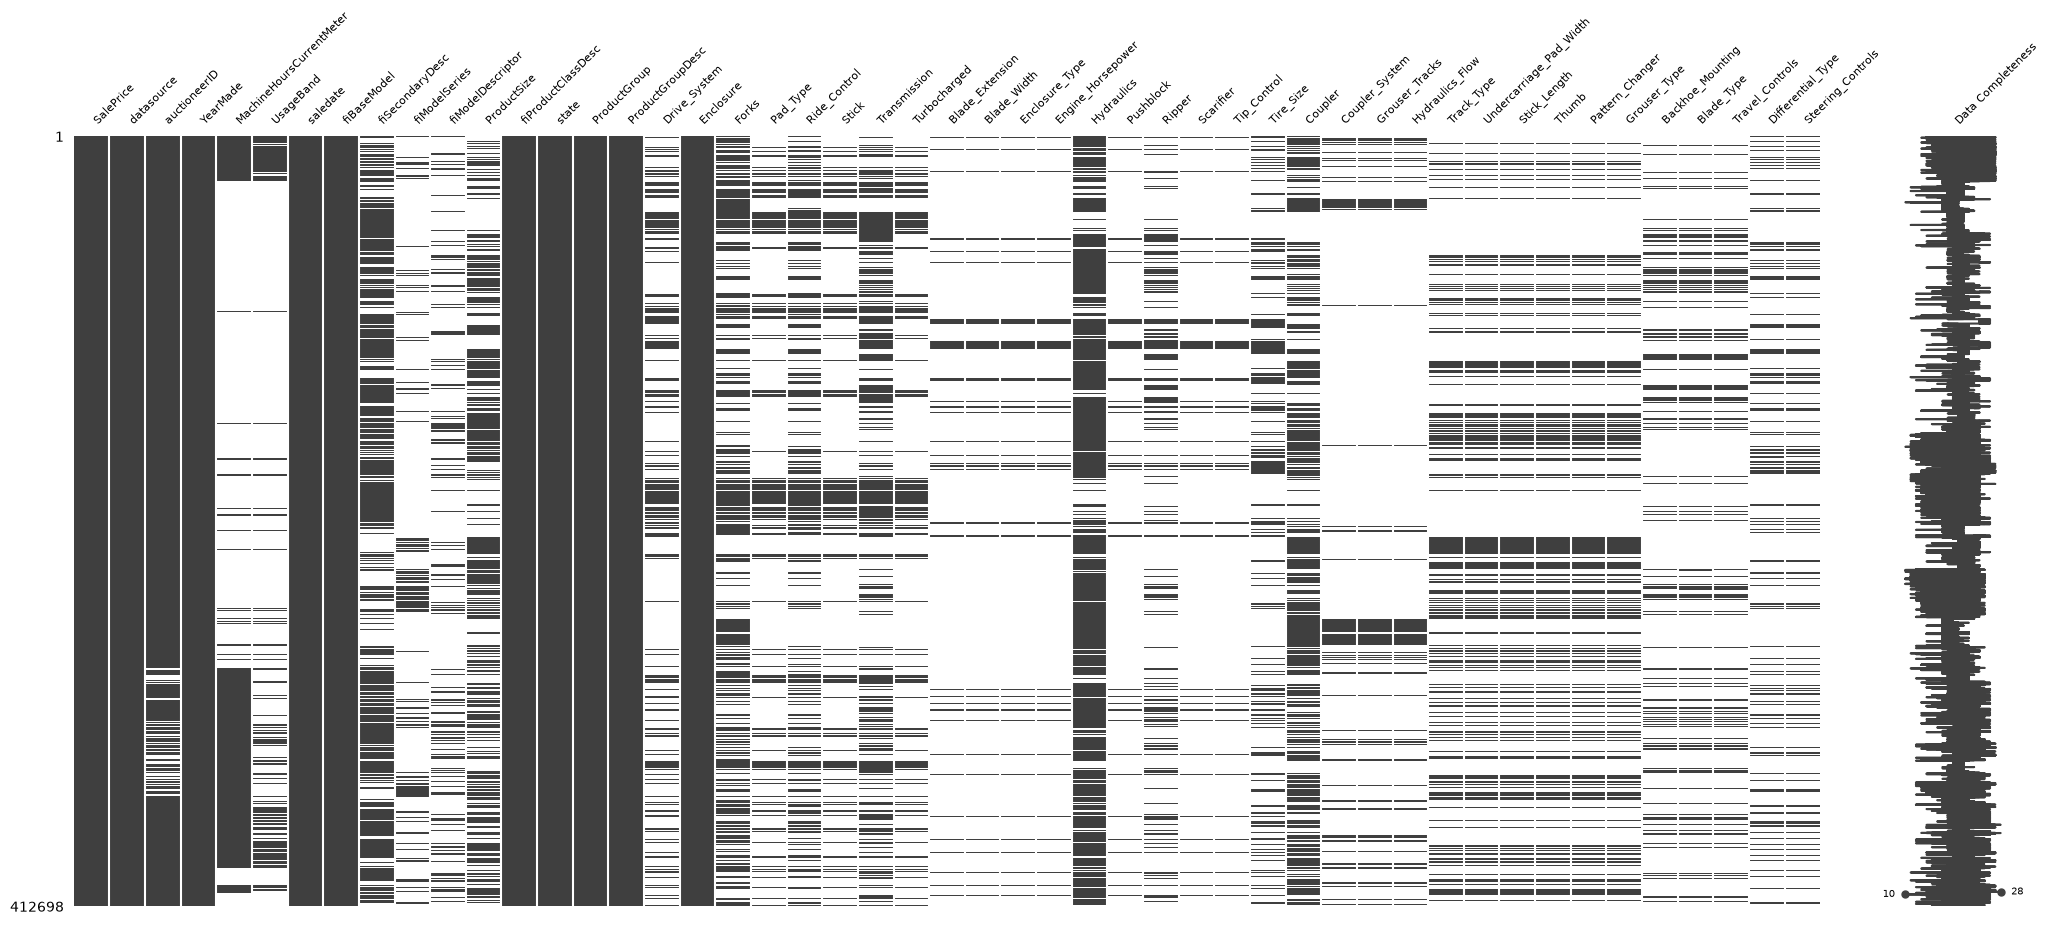

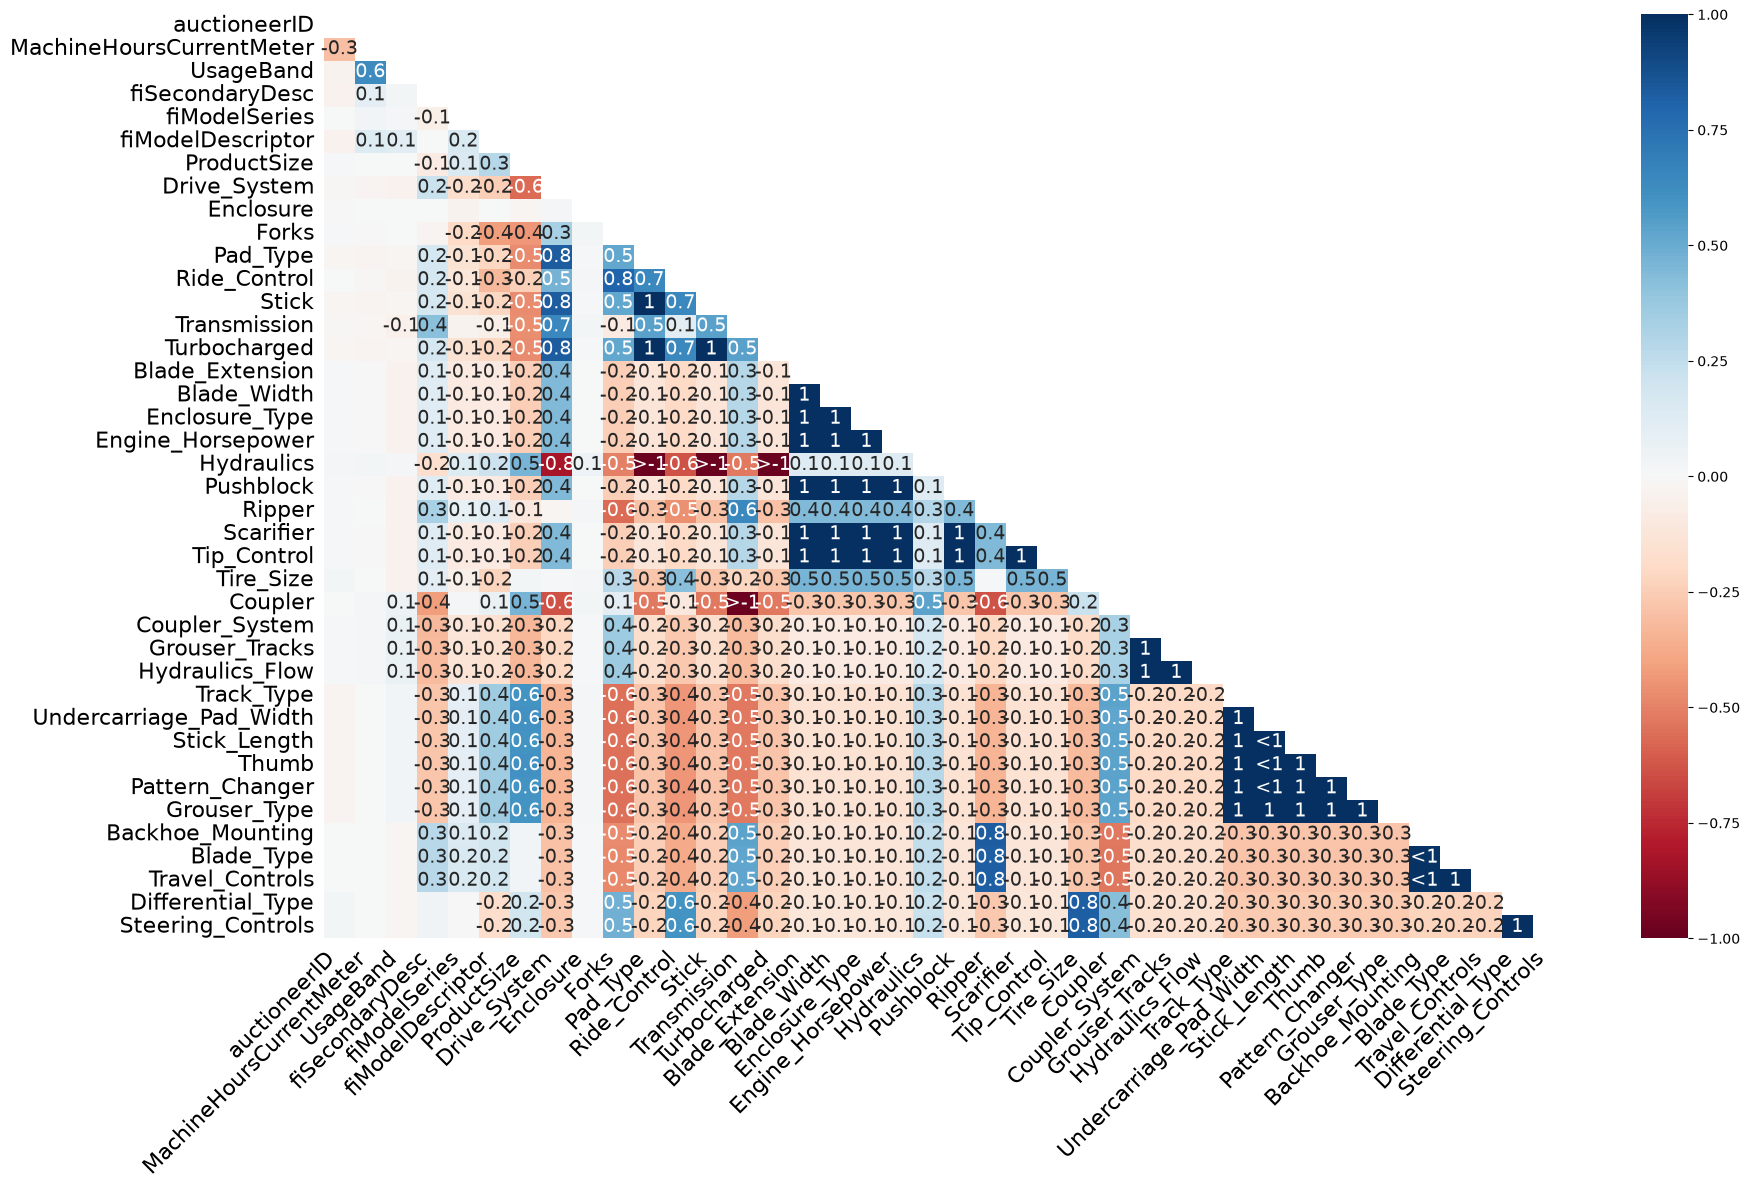

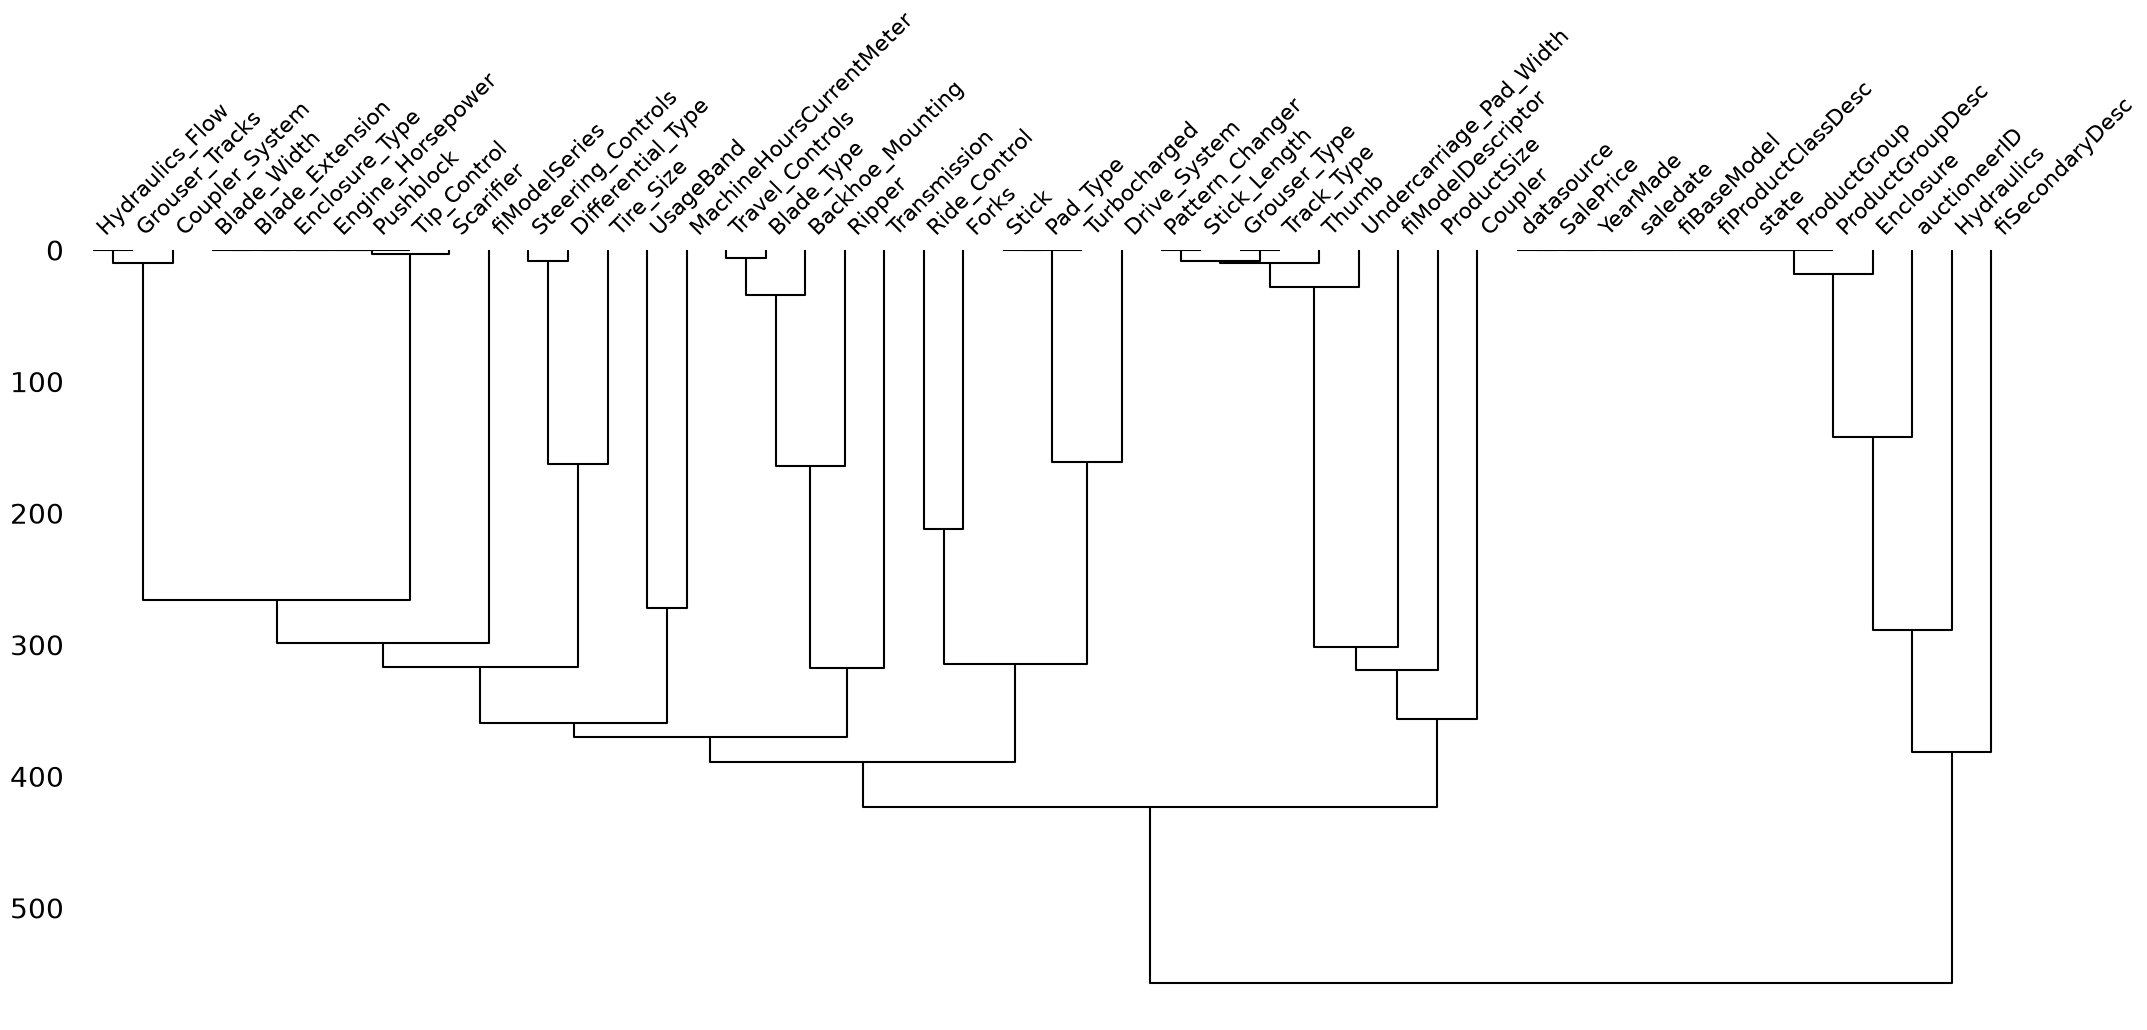

In [91]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df, labels=True, fontsize=8)
plt.show()

msno.heatmap(df)
plt.show()

msno.dendrogram(df)
plt.show()

Modalité valide ? 

In [92]:
with pd.option_context("display.max_columns", None):
    print(df.head(30))

    SalePrice datasource auctioneerID  YearMade  MachineHoursCurrentMeter  \
0     66000.0        121          3.0      2004                      68.0   
1     57000.0        121          3.0      1996                    4640.0   
2     10000.0        121          3.0      2001                    2838.0   
3     38500.0        121          3.0      2001                    3486.0   
4     11000.0        121          3.0      2007                     722.0   
5     26500.0        121          3.0      2004                     508.0   
6     21000.0        121          3.0      1993                   11540.0   
7     27000.0        121          3.0      2001                    4883.0   
8     21500.0        121          3.0      2008                     302.0   
9     65000.0        121          3.0      1000                   20700.0   
10    24000.0        121          3.0      2004                    1414.0   
11    22500.0        121          3.0      1998                    2764.0   

In [93]:
df["ProductSize"].value_counts(dropna=False)

ProductSize
NaN               216605
Medium             64342
Large / Medium     51297
Small              27057
Mini               25721
Large              21396
Compact             6280
Name: count, dtype: int64

In [94]:
import pandas as pd

with pd.option_context("display.max_rows", None):
    print(df["fiProductClassDesc"].value_counts(dropna=False))

fiProductClassDesc
Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth             57542
Track Type Tractor, Dozer - 20.0 to 75.0 Horsepower                 18131
Wheel Loader - 150.0 to 175.0 Horsepower                            15537
Track Type Tractor, Dozer - 85.0 to 105.0 Horsepower                15161
Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons               13736
Track Type Tractor, Dozer - 130.0 to 160.0 Horsepower               11530
Hydraulic Excavator, Track - 12.0 to 14.0 Metric Tons               11527
Track Type Tractor, Dozer - 260.0 + Horsepower                      11227
Wheel Loader - 120.0 to 135.0 Horsepower                            10912
Backhoe Loader - 15.0 to 16.0 Ft Standard Digging Depth             10847
Skid Steer Loader - 1351.0 to 1601.0 Lb Operating Capacity           9546
Skid Steer Loader - 1601.0 to 1751.0 Lb Operating Capacity           9296
Motorgrader - 145.0 to 170.0 Horsepower                              9071
Hydraulic Excavator

In [95]:
# --- ÉTAPE A : Extraire la spécification technique (après le tiret) ---
# On récupère tout ce qui se trouve après le premier " - "
df["spec_*"] = df["fiProductClassDesc"].str.split(" - ", n=1).str[1]

# --- ÉTAPE B : Suppression des colonnes redondantes ---
colonnes_a_supprimer = [
    "fiProductClassDesc",   # Redondant avec ProductGroup/ProductGroupDesc + nouvelle spec
    "ProductGroupDesc"    # Redondant avec product group 
]
       

df = df.drop(columns=colonnes_a_supprimer)

In [96]:
with pd.option_context("display.max_columns", None):
    print(df.head(30))

    SalePrice datasource auctioneerID  YearMade  MachineHoursCurrentMeter  \
0     66000.0        121          3.0      2004                      68.0   
1     57000.0        121          3.0      1996                    4640.0   
2     10000.0        121          3.0      2001                    2838.0   
3     38500.0        121          3.0      2001                    3486.0   
4     11000.0        121          3.0      2007                     722.0   
5     26500.0        121          3.0      2004                     508.0   
6     21000.0        121          3.0      1993                   11540.0   
7     27000.0        121          3.0      2001                    4883.0   
8     21500.0        121          3.0      2008                     302.0   
9     65000.0        121          3.0      1000                   20700.0   
10    24000.0        121          3.0      2004                    1414.0   
11    22500.0        121          3.0      1998                    2764.0   

In [97]:
with pd.option_context("display.max_rows", None): print(df["spec_*"].value_counts())

spec_*
14.0 to 15.0 Ft Standard Digging Depth    57542
20.0 to 75.0 Horsepower                   18131
150.0 to 175.0 Horsepower                 15537
85.0 to 105.0 Horsepower                  15161
21.0 to 24.0 Metric Tons                  13736
130.0 to 160.0 Horsepower                 11530
12.0 to 14.0 Metric Tons                  11527
260.0 + Horsepower                        11227
120.0 to 135.0 Horsepower                 10912
15.0 to 16.0 Ft Standard Digging Depth    10847
1351.0 to 1601.0 Lb Operating Capacity     9546
1601.0 to 1751.0 Lb Operating Capacity     9296
145.0 to 170.0 Horsepower                  9071
33.0 to 40.0 Metric Tons                   9022
1751.0 to 2201.0 Lb Operating Capacity     7922
160.0 to 190.0 Horsepower                  7764
175.0 to 200.0 Horsepower                  7743
1251.0 to 1351.0 Lb Operating Capacity     7500
6.0 to 8.0 Metric Tons                     7433
45.0 to 130.0 Horsepower                   7302
100.0 to 110.0 Horsepower        

Création de colonnes liées aux spec

In [98]:
import numpy as np

# 1. Extraction des unités par motifs textuels
conditions_unite = [
    df["spec_*"].str.contains("Horsepower", na=False),
    df["spec_*"].str.contains("Metric Tons", na=False),
    df["spec_*"].str.contains("Digging Depth", na=False),
    df["spec_*"].str.contains("Operating Capacity", na=False),
]

labels_unite = ["Horsepower", "Metric Tons", "Digging Depth (Ft)", "Lb Operating Capacity"]

df["spec_unit"] = np.select(conditions_unite, labels_unite, default="Unidentified")

# 2. Extraction vectorisée des bornes numériques (borne 1 et borne 2)
# Pattern : capture jusqu'à 2 groupes de chiffres avec ou sans décimale
extracted_bounds = df["spec_*"].str.extract(r"(\d+\.?\d*)(?:\s+to\s+(\d+\.?\d*))?")

min_val = extracted_bounds[0].astype(float)
max_val = extracted_bounds[1].astype(float)

# 3. Calcul de la valeur centrale représentative :
# - Si intervalle (ex: 14.0 to 15.0) -> moyenne (14.5)
# - Si borne ouverte (ex: 260.0 +) -> 260.0
# - Si Unidentified -> NaN
df["spec_value"] = np.where(max_val.notna(), (min_val + max_val) / 2, min_val)

In [99]:
# Liste des unités que tu as extraites
unites_uniques = df["spec_unit"].unique()

# Boucle pour créer une colonne dédiée par unité
for unit in unites_uniques:
    if unit == "Unidentified":
        continue
    
    # Nom de la nouvelle colonne propre (ex: "spec_horsepower")
    col_name = "spec_" + unit.lower().replace(" ", "_").replace("(", "").replace(")", "")
    
    # On met la valeur si c'est la bonne unité, sinon NaN
    df[col_name] = np.where(df["spec_unit"] == unit, df["spec_value"], np.nan)

# Optionnel : tu peux maintenant supprimer les colonnes intermédiaires devenues inutiles
df = df.drop(columns=["spec_unit", "spec_value", "spec_*"])

In [100]:
with pd.option_context("display.max_columns", None): print(df.head())

   SalePrice datasource auctioneerID  YearMade  MachineHoursCurrentMeter  \
0    66000.0        121          3.0      2004                      68.0   
1    57000.0        121          3.0      1996                    4640.0   
2    10000.0        121          3.0      2001                    2838.0   
3    38500.0        121          3.0      2001                    3486.0   
4    11000.0        121          3.0      2007                     722.0   

  UsageBand   saledate fiBaseModel fiSecondaryDesc fiModelSeries  \
0       Low 2006-11-16         521               D           NaN   
1       Low 2004-03-26         950               F            II   
2      High 2004-02-26         226             NaN           NaN   
3      High 2011-05-19       PC120             NaN           -6E   
4    Medium 2009-07-23        S175             NaN           NaN   

  fiModelDescriptor ProductSize           state ProductGroup Drive_System  \
0               NaN         NaN         Alabama          

Vérifications du bornages des variables numérique 

In [101]:
with pd.option_context("display.max_rows", None):
    print(df.select_dtypes(include="number").agg(["min", "median","max"]).T)

                               min   median        max
SalePrice                   4750.0  24000.0   142000.0
YearMade                    1000.0   1995.0     2014.0
MachineHoursCurrentMeter       0.0      0.0  2483300.0
spec_horsepower               20.0    142.5     1000.0
spec_lb_operating_capacity   350.5   1676.0     2701.0
spec_metric_tons               1.0     17.5      300.0
spec_digging_depth_ft          7.0     14.5       16.0


In [102]:
df = zero_vers_nan(df, "MachineHoursCurrentMeter")
df = Transformation_binaire(df, "MachineHoursCurrentMeter", "hours_reported")
df = remplacer_au_dessus_seuil(df, "MachineHoursCurrentMeter", 40000)


In [103]:
df["MachineHoursCurrentMeter"].isna().sum()

np.int64(339635)

In [104]:
df["YearMade"] = df["YearMade"].astype(int)

In [105]:
with pd.option_context("display.max_rows", None):
    print(df.select_dtypes(include="number").agg(["min", "median","max"]).T)

                               min   median       max
SalePrice                   4750.0  24000.0  142000.0
YearMade                    1000.0   1995.0    2014.0
MachineHoursCurrentMeter       1.0   3180.0   39767.0
spec_horsepower               20.0    142.5    1000.0
spec_lb_operating_capacity   350.5   1676.0    2701.0
spec_metric_tons               1.0     17.5     300.0
spec_digging_depth_ft          7.0     14.5      16.0
hours_reported                 0.0      0.0       1.0


Traitement des valeurs incohérentes YearMade

In [106]:
with pd.option_context("display.max_rows",None):print(df["YearMade"].value_counts().sort_index())

YearMade
1000    39391
1919      127
1920       17
1937        1
1942        1
1947        1
1948        3
1949        1
1950        8
1951        7
1952        6
1953        7
1954        3
1955        5
1956       20
1957       16
1958       25
1959       28
1960       97
1961       99
1962      145
1963      250
1964      418
1965      675
1966      951
1967     1104
1968     1260
1969     1544
1970     1321
1971     1720
1972     2141
1973     2547
1974     3113
1975     3240
1976     2718
1977     4425
1978     5693
1979     5613
1980     4744
1981     4190
1982     3048
1983     4603
1984     6174
1985     6547
1986     7588
1987    10191
1988    10546
1989    10785
1990    10379
1991     7461
1992     7711
1993    11181
1994    14471
1995    15806
1996    17001
1997    19269
1998    21751
1999    19274
2000    17238
2001    13385
2002    12473
2003    14661
2004    20914
2005    22096
2006    13426
2007     5048
2008     1691
2009      212
2010       58
2011       31
2012       

# Nettoyage de l'année de fabrication (`YearMade`)

L'exploration de la variable `YearMade` révèle plusieurs valeurs aberrantes :
- Une valeur sentinelle `1000` (près de 40 000 entrées).
- Des erreurs de saisie anciennes (ex: un pic en `1919`).
- Des années de fabrication postérieures à la date de vente (`> 2012`).

**Action :** Restriction des dates à une fenêtre historiquement cohérente **[1950 - 2012]**. Les valeurs aberrantes sont converties en `NaN` afin de ne pas fausser le futur calcul de l'âge de la machine.

In [107]:
df = nettoyer_hors_bornes(df, "YearMade", borne_min=1950, borne_max=2012)

In [108]:
row_rare = df.loc[df["YearMade"]==1000]
print(row_rare)

Empty DataFrame
Columns: [SalePrice, datasource, auctioneerID, YearMade, MachineHoursCurrentMeter, UsageBand, saledate, fiBaseModel, fiSecondaryDesc, fiModelSeries, fiModelDescriptor, ProductSize, state, ProductGroup, Drive_System, Enclosure, Forks, Pad_Type, Ride_Control, Stick, Transmission, Turbocharged, Blade_Extension, Blade_Width, Enclosure_Type, Engine_Horsepower, Hydraulics, Pushblock, Ripper, Scarifier, Tip_Control, Tire_Size, Coupler, Coupler_System, Grouser_Tracks, Hydraulics_Flow, Track_Type, Undercarriage_Pad_Width, Stick_Length, Thumb, Pattern_Changer, Grouser_Type, Backhoe_Mounting, Blade_Type, Travel_Controls, Differential_Type, Steering_Controls, spec_horsepower, spec_lb_operating_capacity, spec_metric_tons, spec_digging_depth_ft, hours_reported]
Index: []

[0 rows x 52 columns]


Le log sert surtout à limiter l'effet des grosses valeurs quand la perte est quadratique (RMSE), parce que le carré amplifie les erreurs sur les prix élevés. MAE et pinball loss ont un gradient constant (±τ ou ±(1-τ)), pas proportionnel à l'ampleur de l'erreur  elles n'ont pas ce problème d'amplification, donc pas besoin de symétriser la distribution en amont. 


In [109]:
with pd.option_context("display.max_columns", None): print(df.head())

   SalePrice datasource auctioneerID  YearMade  MachineHoursCurrentMeter  \
0    66000.0        121          3.0    2004.0                      68.0   
1    57000.0        121          3.0    1996.0                    4640.0   
2    10000.0        121          3.0    2001.0                    2838.0   
3    38500.0        121          3.0    2001.0                    3486.0   
4    11000.0        121          3.0    2007.0                     722.0   

  UsageBand   saledate fiBaseModel fiSecondaryDesc fiModelSeries  \
0       Low 2006-11-16         521               D           NaN   
1       Low 2004-03-26         950               F            II   
2      High 2004-02-26         226             NaN           NaN   
3      High 2011-05-19       PC120             NaN           -6E   
4    Medium 2009-07-23        S175             NaN           NaN   

  fiModelDescriptor ProductSize           state ProductGroup Drive_System  \
0               NaN         NaN         Alabama          

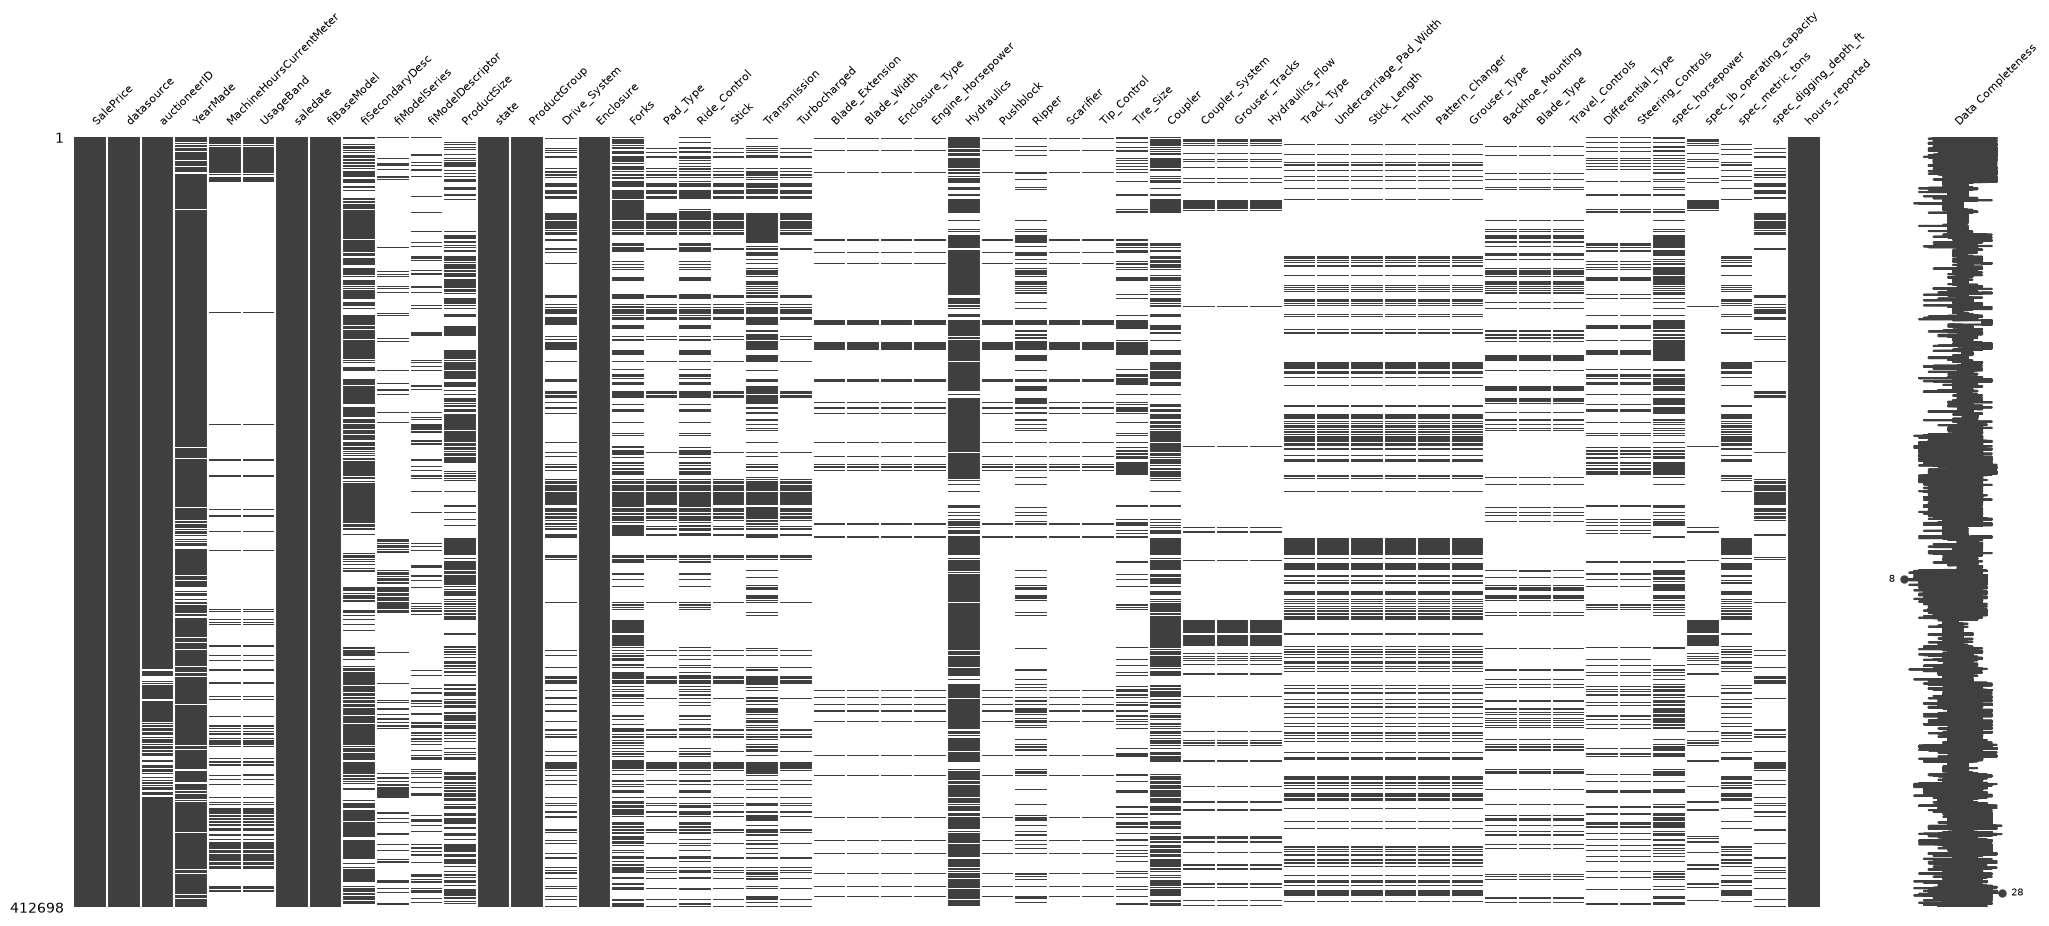

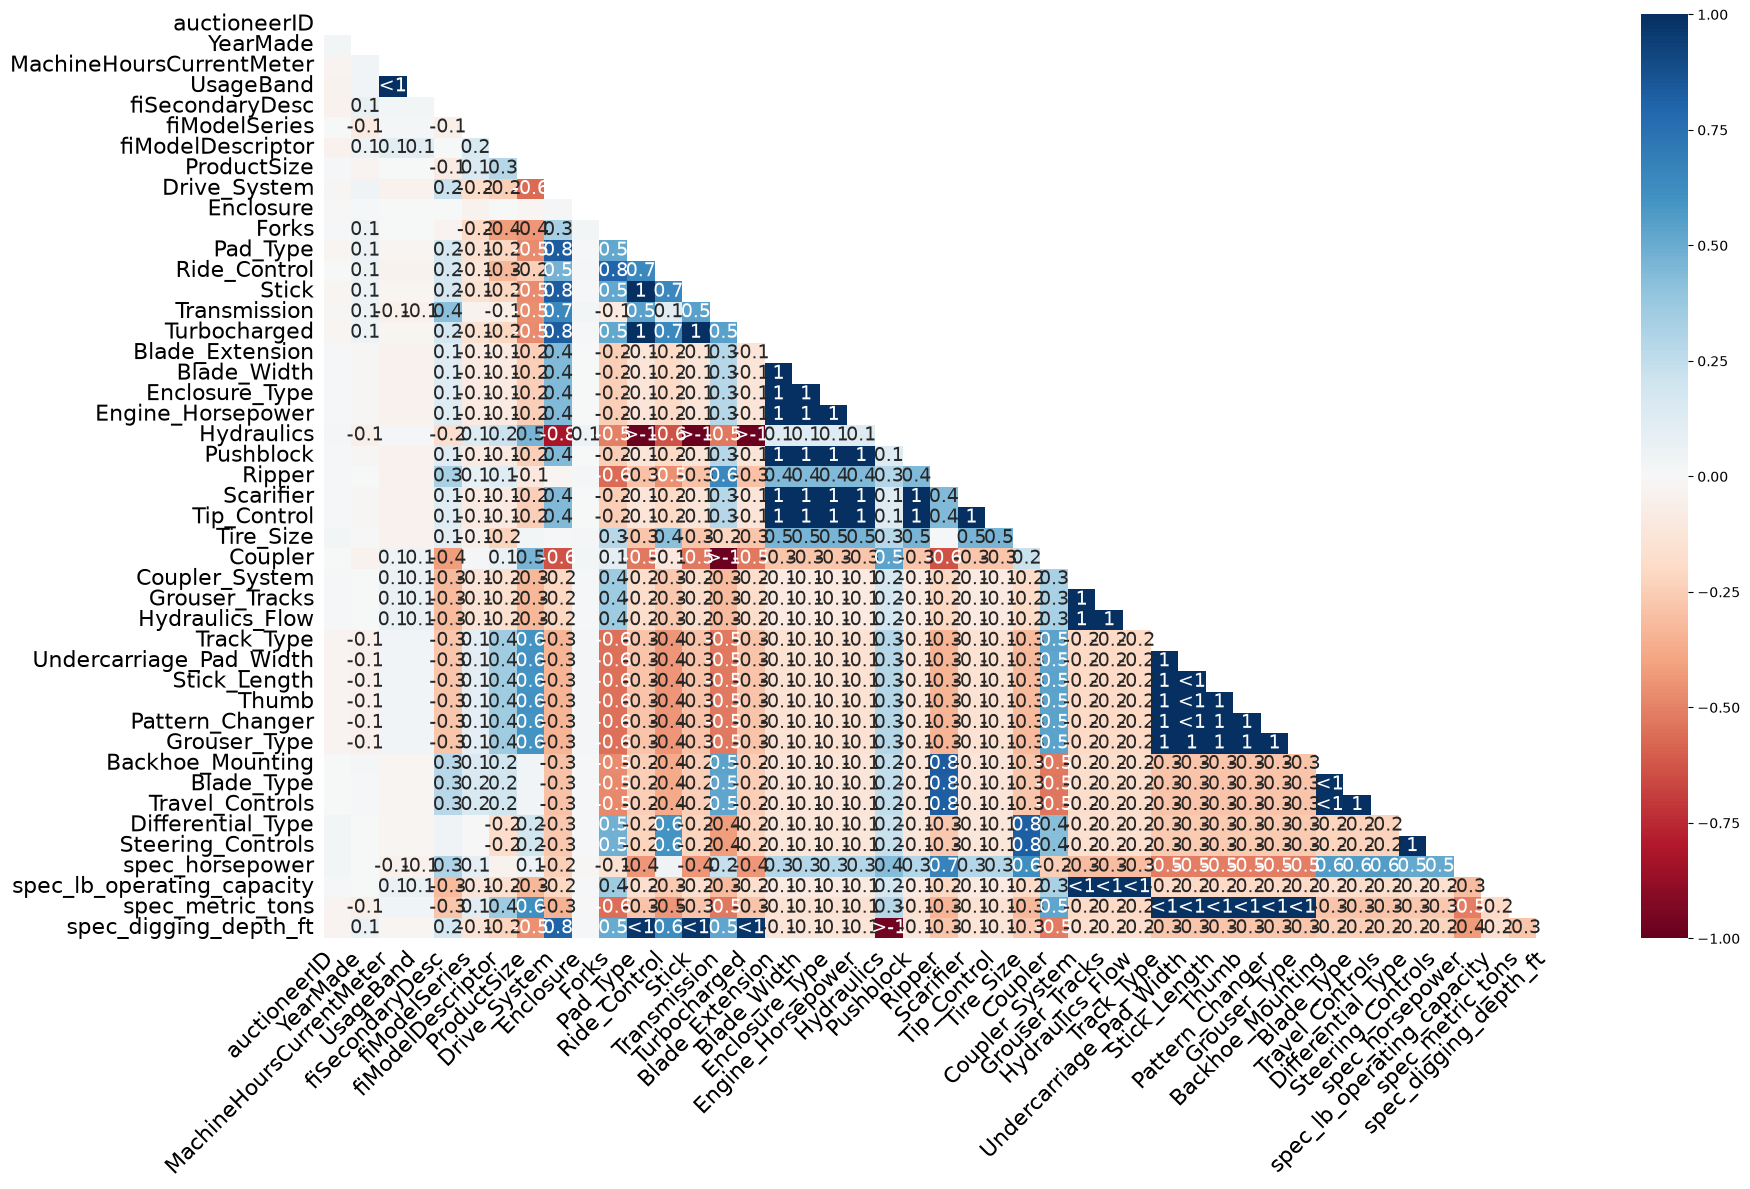

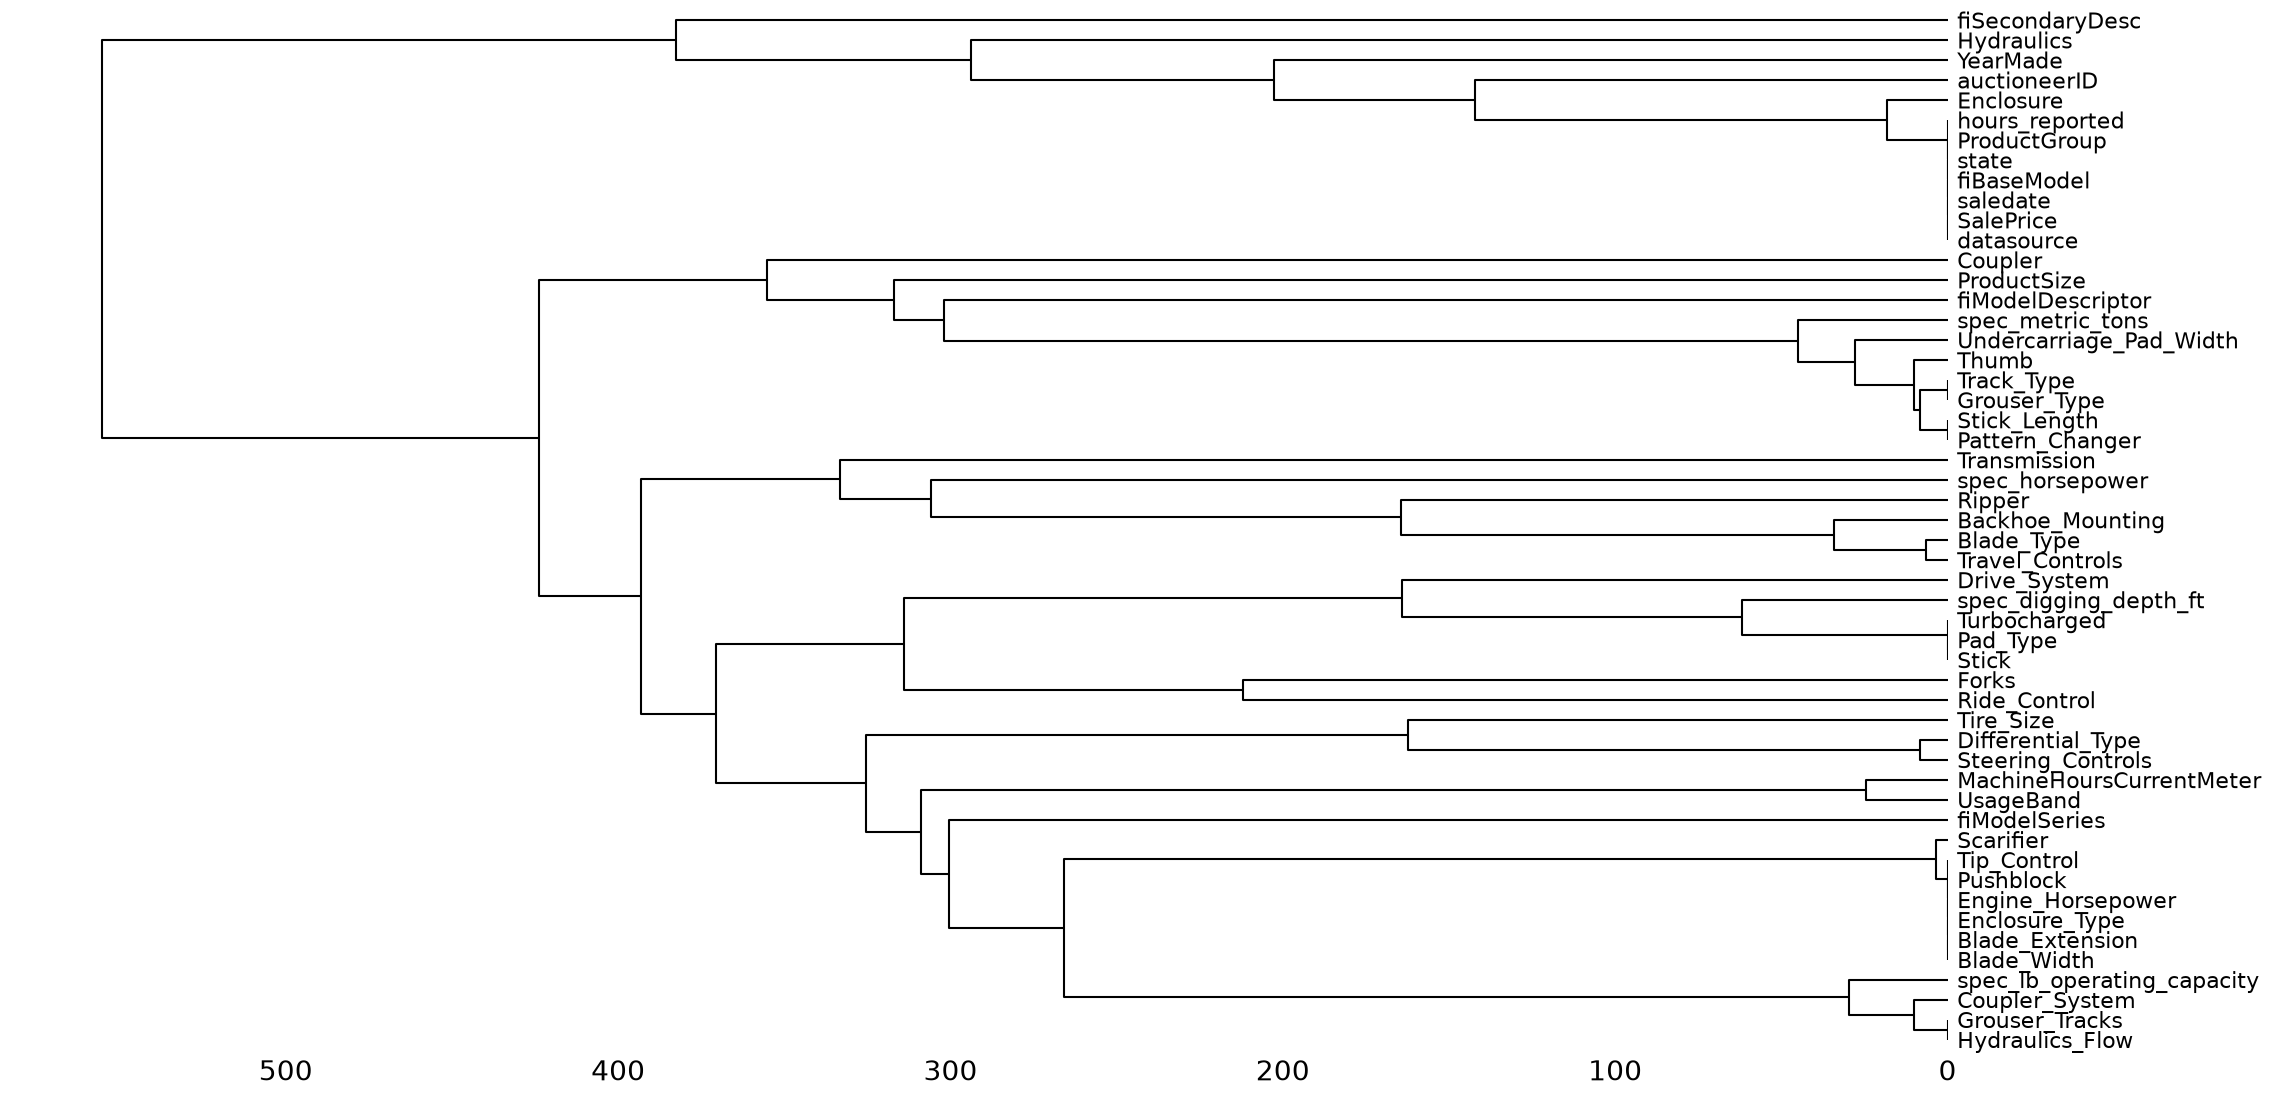

In [110]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df, labels=True, fontsize=8)
plt.show()

msno.heatmap(df)
plt.show()

msno.dendrogram(df)
plt.show()

In [111]:
df_non_num=df.select_dtypes(exclude="number")
nan_tot = df_non_num.isnull().sum()
colonnes_avec_nan= nan_tot[nan_tot>0].index


variablesgardees = variable_nan_structurel(df, "ProductGroup", colonnes_avec_nan, 5, 95)
print(variablesgardees)
len(variablesgardees)

['Drive_System', 'Forks', 'Pad_Type', 'Ride_Control', 'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension', 'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics', 'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size', 'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow', 'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb', 'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type', 'Travel_Controls', 'Differential_Type', 'Steering_Controls']


32

création des deux types d'imputation a tester sur la modélisation:granulaire "Non appliquable"+"Missing" VS "Non appliquable" (Methode B resp Methode A)

In [112]:
df_methodeA = df.copy()
df_methodeB = df.copy()



# BLOC MÉTHODE A BLOC-A


Toutes les cellules de ce bloc ne doivent référencer que `df_methodeA`. Aucune cellule ici ne doit lire ou écrire `df_methodeB`.

Methode A

In [113]:
for i in variablesgardees:
    df_methodeA.loc[df_methodeA[i].isna(), i] = "Missing"


# `UsageBand`

`UsageBand` compare les heures d'une machine à la moyenne de son `fiBaseModel` (data dictionary). Quand `MachineHoursCurrentMeter = 0`, ce ratio est indéterminé : aucun niveau `Low`/`Medium`/`High` ne peut être calculé.

Vérifié par `groupby("MachineHoursCurrentMeter")["UsageBand"]` : NaN à 100 % quand `MachineHoursCurrentMeter == 0`, à 0 % sinon  le lien est direct.

L'absence n'est donc pas un défaut de collecte propre à `UsageBand`, mais une conséquence arithmétique automatique héritée de `MachineHoursCurrentMeter`. Imputation par `"Missing"`, cohérent avec le reste du pipeline..

In [114]:
rarelistA = ["ProductSize", "Forks", "Ride_Control", "Transmission", "Coupler"]

for col in rarelistA:
    df_methodeA[col] = df_methodeA[col].fillna("Missing")

df_methodeA["Enclosure"] = df_methodeA["Enclosure"].fillna("Missing")

df_methodeA["UsageBand"] = df_methodeA["UsageBand"].fillna("Missing")


df_methodeA.isnull().sum()

SalePrice                          0
datasource                         0
auctioneerID                   20136
YearMade                       39545
MachineHoursCurrentMeter      339635
UsageBand                          0
saledate                           0
fiBaseModel                        0
fiSecondaryDesc               140727
fiModelSeries                 354031
fiModelDescriptor             337882
ProductSize                        0
state                              0
ProductGroup                       0
Drive_System                       0
Enclosure                          0
Forks                              0
Pad_Type                           0
Ride_Control                       0
Stick                              0
Transmission                       0
Turbocharged                       0
Blade_Extension                    0
Blade_Width                        0
Enclosure_Type                     0
Engine_Horsepower                  0
Hydraulics                         0
P

In [115]:
df_non_numA = df_methodeA.select_dtypes(exclude="number")# 1. Reprendre la liste des colonnes non numériques qui ont des NaN
nansA = df_non_numA.isna().sum()
colonnes_avec_nanA = nansA[nansA > 0].index

# 2. Faire la différence entre toutes les colonnes ayant des NaN et celles gardées par la fonction
variables_non_structurellesB = list(set(colonnes_avec_nanA) - set(variablesgardees))

print("Variables à NaN non structurel :")
print(variables_non_structurellesB)
print(f"Nombre total : {len(variables_non_structurellesB)}")

Variables à NaN non structurel :
['fiModelSeries', 'auctioneerID', 'fiSecondaryDesc', 'fiModelDescriptor']
Nombre total : 4


In [116]:
var_nan_non_structurel=["fiModelSeries","fiModelDescriptor","fiSecondaryDesc"]
for i in var_nan_non_structurel:
    df_methodeA[i]=df_methodeA[i].fillna("Missing") 

In [117]:
df_methodeA["auctioneerID"] = df_methodeA["auctioneerID"].fillna("Missing")

# Feature engineering : Méthode A A-FEATENG

In [118]:
df_methodeA["sale_year"] = df_methodeA["saledate"].dt.year
df_methodeA["sale_month"] = df_methodeA["saledate"].dt.month
df_methodeA["sale_day"] = df_methodeA["saledate"].dt.day
df_methodeA["sale_quarter"] = df_methodeA["saledate"].dt.quarter


In [119]:
df_methodeA["auctioneerID"].value_counts(dropna=False)


auctioneerID
1.0        192773
2.0         57441
3.0         30288
4.0         20877
Missing     20136
99.0        12042
6.0         11950
7.0          7847
8.0          7419
5.0          7002
10.0         5876
9.0          4764
11.0         3823
12.0         3610
13.0         3068
18.0         2359
14.0         2277
20.0         2238
19.0         2074
16.0         1807
15.0         1742
21.0         1601
22.0         1429
24.0         1357
23.0         1322
17.0         1275
27.0         1150
25.0          959
28.0          860
26.0          796
0.0           536
Name: count, dtype: int64

Age de la machine

In [120]:
df_methodeA["machine_age"]=df_methodeA["sale_year"]-df_methodeA["YearMade"]
print(df_methodeA["machine_age"])


0          2.0
1          8.0
2          3.0
3         10.0
4          2.0
          ... 
412693     7.0
412694     7.0
412695     7.0
412696     6.0
412697     6.0
Name: machine_age, Length: 412698, dtype: float64


intensité d'uitilisation

In [121]:
df_methodeA["heures_par_an"]=df_methodeA["MachineHoursCurrentMeter"]/df_methodeA["machine_age"]
print(df_methodeA["heures_par_an"])


0          34.0
1         580.0
2         946.0
3         348.6
4         361.0
          ...  
412693      NaN
412694      NaN
412695      NaN
412696      NaN
412697      NaN
Name: heures_par_an, Length: 412698, dtype: float64


Impact de la recession

In [122]:
df_methodeA["is_recession"] = np.where(df_methodeA["sale_year"].isin([2008, 2009]), 1, 0)


Gamme du produit

In [123]:
# Extrait le bloc de lettres au début de la chaîne (ex: "WA" dans "WA320")
df_methodeA["model_prefix"] = df_methodeA["fiBaseModel"].str.extract(r'^([A-Za-z]+)', expand=False)
# Remplacer les valeurs manquantes (les modèles purement numériques)
df_methodeA["model_prefix"] = df_methodeA["model_prefix"].fillna("Numeric")
# Regardons le résultat des plus grandes familles :
print(df_methodeA["model_prefix"].value_counts(dropna=False))


model_prefix
Numeric    259667
D           63206
PC          16640
EX           9320
WA           7405
            ...  
KL              1
V               1
IS              1
SUPER           1
HW              1
Name: count, Length: 158, dtype: int64


In [124]:
with pd.option_context("display.max_rows", None):print(df_methodeA.isnull().sum())


SalePrice                          0
datasource                         0
auctioneerID                       0
YearMade                       39545
MachineHoursCurrentMeter      339635
UsageBand                          0
saledate                           0
fiBaseModel                        0
fiSecondaryDesc                    0
fiModelSeries                      0
fiModelDescriptor                  0
ProductSize                        0
state                              0
ProductGroup                       0
Drive_System                       0
Enclosure                          0
Forks                              0
Pad_Type                           0
Ride_Control                       0
Stick                              0
Transmission                       0
Turbocharged                       0
Blade_Extension                    0
Blade_Width                        0
Enclosure_Type                     0
Engine_Horsepower                  0
Hydraulics                         0
P

In [125]:
df_methodeA["heures_par_an"]=df_methodeA["heures_par_an"].replace([np.inf,-np.inf],np.nan)

In [126]:
nan_col_numA =["spec_horsepower","spec_lb_operating_capacity","spec_metric_tons","spec_digging_depth_ft","machine_age","heures_par_an"]
for col in nan_col_numA:
    df_methodeA[col]=df_methodeA[col].fillna(-1)

In [127]:
df_methodeA[nan_col_numA].isnull().sum()

spec_horsepower               0
spec_lb_operating_capacity    0
spec_metric_tons              0
spec_digging_depth_ft         0
machine_age                   0
heures_par_an                 0
dtype: int64

In [128]:
np.isinf(df_methodeA["heures_par_an"]).sum()


np.int64(0)


# BLOC MÉTHODE B BLOC-B


Toutes les cellules de ce bloc ne doivent référencer que `df_methodeB`. Aucune cellule ici ne doit lire ou écrire `df_methodeA`.

Methode B

note : la cellule suivante occupait la position 43 dans le fichier source, entre les sections A et B : déplacée ici telle quelle (code inchangé) car elle ne teste que `df_methodeB`.

In [129]:
df_methodeB.select_dtypes(exclude="number").isnull().sum()

datasource                      0
auctioneerID                20136
UsageBand                  339028
saledate                        0
fiBaseModel                     0
fiSecondaryDesc            140727
fiModelSeries              354031
fiModelDescriptor          337882
ProductSize                216605
state                           0
ProductGroup                    0
Drive_System               305611
Enclosure                     334
Forks                      214983
Pad_Type                   331602
Ride_Control               259970
Stick                      331602
Transmission               224691
Turbocharged               331602
Blade_Extension            386715
Blade_Width                386715
Enclosure_Type             386715
Engine_Horsepower          386715
Hydraulics                  82565
Pushblock                  386715
Ripper                     305753
Scarifier                  386704
Tip_Control                386715
Tire_Size                  315060
Coupler       

In [130]:
df_methodeB = imputer_valeurs_rares(df_methodeB, "ProductGroup",variablesgardees, 95, "Non applicable")

for col in variablesgardees:
    df_methodeB[col] = df_methodeB[col].fillna("Missing")

df_methodeB["Enclosure"] = df_methodeB["Enclosure"].fillna("Missing")

df_methodeB["UsageBand"] = df_methodeB["UsageBand"].fillna("Missing")

df_methodeB.isnull().sum()



SalePrice                          0
datasource                         0
auctioneerID                   20136
YearMade                       39545
MachineHoursCurrentMeter      339635
UsageBand                          0
saledate                           0
fiBaseModel                        0
fiSecondaryDesc               140727
fiModelSeries                 354031
fiModelDescriptor             337882
ProductSize                   216605
state                              0
ProductGroup                       0
Drive_System                       0
Enclosure                          0
Forks                              0
Pad_Type                           0
Ride_Control                       0
Stick                              0
Transmission                       0
Turbocharged                       0
Blade_Extension                    0
Blade_Width                        0
Enclosure_Type                     0
Engine_Horsepower                  0
Hydraulics                         0
P

In [131]:
rarelistB = ["ProductSize", "Forks", "Ride_Control", "Transmission", "Coupler"]
df_methodeB = imputer_valeurs_rares(df_methodeB, "ProductGroup",rarelistB, 95, "Non applicable")

for col in rarelistB:
    df_methodeB[col] = df_methodeB[col].fillna("Missing")

df_methodeB.isnull().sum()


SalePrice                          0
datasource                         0
auctioneerID                   20136
YearMade                       39545
MachineHoursCurrentMeter      339635
UsageBand                          0
saledate                           0
fiBaseModel                        0
fiSecondaryDesc               140727
fiModelSeries                 354031
fiModelDescriptor             337882
ProductSize                        0
state                              0
ProductGroup                       0
Drive_System                       0
Enclosure                          0
Forks                              0
Pad_Type                           0
Ride_Control                       0
Stick                              0
Transmission                       0
Turbocharged                       0
Blade_Extension                    0
Blade_Width                        0
Enclosure_Type                     0
Engine_Horsepower                  0
Hydraulics                         0
P

In [132]:
type(df_methodeB)

pandas.DataFrame

In [133]:
df_non_numB = df_methodeB.select_dtypes(exclude="number")# 1. Reprendre la liste des colonnes non numériques qui ont des NaN
nansB = df_non_numB.isna().sum()
colonnes_avec_nanB = nansB[nansB > 0].index

# 2. Faire la différence entre toutes les colonnes ayant des NaN et celles gardées par la fonction
variables_non_structurellesB = list(set(colonnes_avec_nanB) - set(variablesgardees))

print("Variables à NaN non structurel :")
print(variables_non_structurellesB)
print(f"Nombre total : {len(variables_non_structurellesB)}")

Variables à NaN non structurel :
['fiModelSeries', 'auctioneerID', 'fiSecondaryDesc', 'fiModelDescriptor']
Nombre total : 4


# Typologie et traitement des variables à NaN non structurels

Les 7 variables isolées présentent des profils de valeurs manquantes hétérogènes ne relevant pas d'une absence structurelle nette par type de machine :

*   **`fiModelSeries`, `fiModelDescriptor`, `fiSecondaryDesc` :** Caractérisées par un continuum diffus de NaN (absence de bimodalité franche). Traitement appliqué : imputation par la modalité explicite `"Missing"`.
*   **`UsageBand` :** Forte corrélation avec les heures relevées (`MachineHoursCurrentMeter`). Traitement appliqué : remplacement des NaN par `"Non renseigné"` pour préserver l'information lorsque la valeur est absente.
*   **`ProductSize` et `Enclosure` :** Profils mixtes ou résidus de collecte mineurs. Traitement spécifique appliqué selon le diagnostic de distribution.
*   **`auctioneerID` :** Identifiant nominal du commissaire-priseur comportant quelques oublis de saisie, traité comme une variable catégorielle.

In [134]:
print(df["ProductSize"].value_counts(dropna=False))

ProductSize
NaN               216605
Medium             64342
Large / Medium     51297
Small              27057
Mini               25721
Large              21396
Compact             6280
Name: count, dtype: int64


In [135]:
print(df["Enclosure"].value_counts(dropna=False))

Enclosure
OROPS                  177971
EROPS                  141769
EROPS w AC              92601
NaN                       334
EROPS AC                   18
NO ROPS                     3
None or Unspecified         2
Name: count, dtype: int64


In [136]:
with pd.option_context("display.max_rows",None):(print(df.groupby("datasource")["ProductSize"].apply(lambda x: x.isnull().mean() * 100).sort_values(ascending=False)))

datasource
149    59.426857
132    52.807007
136    51.788955
121    50.236195
172    40.984705
173     0.000000
Name: ProductSize, dtype: float64


In [137]:
with pd.option_context("display.max_rows",None):(print(df.groupby("auctioneerID")["ProductSize"].apply(lambda x: x.isnull().mean() * 100).sort_values(ascending=False)))

auctioneerID
25.0    71.949948
18.0    71.343790
21.0    64.896939
22.0    63.470959
14.0    63.153272
20.0    63.047364
26.0    62.814070
28.0    62.558140
11.0    59.639027
99.0    58.993523
0.0     58.768657
12.0    57.562327
27.0    56.000000
8.0     55.452217
10.0    55.122532
13.0    53.943937
7.0     52.797247
2.0     52.753260
9.0     52.518892
1.0     51.660243
3.0     50.861727
17.0    50.745098
4.0     50.217943
6.0     50.192469
23.0    49.092284
16.0    47.315993
19.0    46.673095
24.0    45.910096
15.0    44.489093
5.0     39.960011
Name: ProductSize, dtype: float64


In [138]:
with pd.option_context("display.max_rows",None):(print(df.groupby("saledate")["ProductSize"].apply(lambda x: x.isnull().mean() * 100).sort_values(ascending=False)))

saledate
2012-04-16    100.000000
2004-07-09    100.000000
2004-07-14    100.000000
1995-05-12    100.000000
2010-07-30    100.000000
1998-12-03    100.000000
2009-10-21    100.000000
2009-10-19    100.000000
2007-04-23    100.000000
2009-04-10    100.000000
2004-02-22    100.000000
2004-02-19    100.000000
2004-02-13    100.000000
2012-03-12    100.000000
2012-02-28    100.000000
2004-07-20    100.000000
2004-03-15    100.000000
2012-02-15    100.000000
2012-02-10    100.000000
2010-07-12    100.000000
2010-07-02    100.000000
1993-06-05    100.000000
2007-04-02    100.000000
2007-03-24    100.000000
1995-08-04    100.000000
2012-02-04    100.000000
1990-03-24    100.000000
1990-03-10    100.000000
2004-02-06    100.000000
2004-01-27    100.000000
2001-05-12    100.000000
2001-06-14    100.000000
2007-02-26    100.000000
2007-02-19    100.000000
1993-10-13    100.000000
1993-10-09    100.000000
2010-06-14    100.000000
2007-05-08    100.000000
2007-05-07    100.000000
2008-02-18    10

# `ProductSize` : diagnostic non structurel

Diagnostic par `ProductGroup` : `BL`, `MG`, `SSL` à 100 % de NaN, `TEX` à ~0,15 %, `TTT` à ~48 %, `WL` à ~32 %  taux intermédiaires incompatibles avec une absence structurelle pure, qui produirait un motif quasi binaire comme observé pour `Engine_Horsepower`.

Vérification par `datasource` : taux de NaN de 0 % (source 173) à ~59 % (source 149) sur la même variable. Vérification par `auctioneerID` : de ~40 % à ~72 % selon le commissaire-priseur.

**Conclusion.** La variabilité selon la source et le commissaire-priseur montre que l'absence de `ProductSize` dépend de qui a fourni ou saisi la donnée, pas du type d'engin  contrairement à `Engine_Horsepower`, dont le motif quasi binaire par `ProductGroup` confirme une absence structurelle réelle.

**Décision.** `ProductSize` est un cas de NaN accidentel, pas structurel. Codé en `"Missing"` plutôt qu'en `"Non applicable"`, pour ne pas affirmer à tort que la taille ne s'applique pas à certains types d'engins.

In [139]:
df_methodeB["ProductSize"]=df_methodeB["ProductSize"].fillna("Missing")

In [140]:
df_methodeB.select_dtypes(exclude="number").isnull().sum()

datasource                      0
auctioneerID                20136
UsageBand                       0
saledate                        0
fiBaseModel                     0
fiSecondaryDesc            140727
fiModelSeries              354031
fiModelDescriptor          337882
ProductSize                     0
state                           0
ProductGroup                    0
Drive_System                    0
Enclosure                       0
Forks                           0
Pad_Type                        0
Ride_Control                    0
Stick                           0
Transmission                    0
Turbocharged                    0
Blade_Extension                 0
Blade_Width                     0
Enclosure_Type                  0
Engine_Horsepower               0
Hydraulics                      0
Pushblock                       0
Ripper                          0
Scarifier                       0
Tip_Control                     0
Tire_Size                       0
Coupler       

In [141]:
df_methodeB["auctioneerID"] = df_methodeB["auctioneerID"].fillna("Missing")

In [142]:
df_methodeB.select_dtypes(exclude="number").isnull().sum()

datasource                      0
auctioneerID                    0
UsageBand                       0
saledate                        0
fiBaseModel                     0
fiSecondaryDesc            140727
fiModelSeries              354031
fiModelDescriptor          337882
ProductSize                     0
state                           0
ProductGroup                    0
Drive_System                    0
Enclosure                       0
Forks                           0
Pad_Type                        0
Ride_Control                    0
Stick                           0
Transmission                    0
Turbocharged                    0
Blade_Extension                 0
Blade_Width                     0
Enclosure_Type                  0
Engine_Horsepower               0
Hydraulics                      0
Pushblock                       0
Ripper                          0
Scarifier                       0
Tip_Control                     0
Tire_Size                       0
Coupler       

In [143]:
with pd.option_context("display.max_rows",None):(print(df.groupby("fiBaseModel")["fiModelDescriptor"].apply(lambda x: x.isnull().mean() * 100).sort_values(ascending=False)))

fiBaseModel
ZX850            100.000000
10               100.000000
100              100.000000
104              100.000000
1066             100.000000
1080             100.000000
ZX17             100.000000
ZX135            100.000000
ZX125            100.000000
ZX110            100.000000
ZL402            100.000000
ZAXIS 270        100.000000
ZAXIS 135        100.000000
155              100.000000
153              100.000000
1500             100.000000
150              100.000000
15               100.000000
1450             100.000000
143              100.000000
1400             100.000000
140              100.000000
14               100.000000
137              100.000000
1340             100.000000
1300             100.000000
1288             100.000000
1760XL           100.000000
1750             100.000000
175              100.000000
1740             100.000000
1737             100.000000
1700             100.000000
170              100.000000
17               100.000000
166     

In [144]:
# 1. Taux de NaN par fiBaseModel (déjà fait, rappelé ici)
taux_nan_par_modele = df.groupby("fiBaseModel")["fiModelDescriptor"].apply(
    lambda x: x.isna().mean() * 100
)

# 2. Nombre de lignes par fiBaseModel
effectif_par_modele = df["fiBaseModel"].value_counts()

# 3. Classement quasi-binaire vs intermédiaire
categorie_modele = pd.cut(
    taux_nan_par_modele,
    bins=[-0.01, 5, 95, 100],
    labels=["quasi_nul", "intermediaire", "quasi_total"]
)

# 4. Proportion du total des LIGNES (pas des groupes) tombant en intermédiaire
resultat = pd.DataFrame({
    "taux_nan": taux_nan_par_modele,
    "effectif": effectif_par_modele,
    "categorie": categorie_modele
})

lignes_intermediaires = resultat.loc[resultat["categorie"] == "intermediaire", "effectif"].sum()
lignes_totales = resultat["effectif"].sum()
proportion_intermediaire = lignes_intermediaires / lignes_totales * 100

print(f"Nombre de fiBaseModel intermédiaires : {(resultat['categorie'] == 'intermediaire').sum()} sur {resultat.shape[0]}")
print(f"Lignes concernées par ces modèles intermédiaires : {lignes_intermediaires} sur {lignes_totales} ({proportion_intermediaire:.2f}%)")

Nombre de fiBaseModel intermédiaires : 226 sur 1961
Lignes concernées par ces modèles intermédiaires : 133931 sur 412698 (32.45%)


# Comparaison avec `Engine_Horsepower`

`Engine_Horsepower` : aucun `fiBaseModel` intermédiaire, motif binaire parfait   hypothèse d'absence structurelle confirmée.

Ici, un tiers des lignes appartient à des modèles où le champ est parfois rempli, parfois non, pour un même `fiBaseModel`. La présence du champ ne dépend donc pas uniquement du gabarit de nommage du modèle : un autre facteur varie ligne à ligne à l'intérieur d'un même modèle   configuration spécifique de la machine vendue, ou facteur de collecte comme pour `ProductSize`.

In [145]:
for col in ["datasource", "auctioneerID"]:
    taux = df.groupby(col)["fiModelDescriptor"].apply(lambda x: x.isna().mean() * 100)
    print(f"--- {col} ---")
    print(f"min: {taux.min():.1f}% / max: {taux.max():.1f}%")

--- datasource ---
min: 68.2% / max: 100.0%
--- auctioneerID ---
min: 71.6% / max: 96.8%


 `fiSecondaryDesc`, `fiModelSeries`, `fiModelDescriptor` : diagnostic non structurel

Trois colonnes concernées : `fiSecondaryDesc` (140 727 NaN), `fiModelSeries` (354 031 NaN), `fiModelDescriptor` (337 882 NaN). `fiModelDesc` se décompose en `fiBaseModel` + `fiSecondaryDesc` + `fiModelSeries` + `fiModelDescriptor`   hypothèse testée : le remplissage suivrait un gabarit de nommage constant par `fiBaseModel`.

**Test 1   par `fiBaseModel`.** Taux de NaN pondéré par le nombre de lignes, classement quasi_nul (≤5%) / intermédiaire (5-95%) / quasi_total (>95%). Résultat : 226 `fiBaseModel` sur 1961 en zone intermédiaire, représentant 32,45 % des lignes (133 931 sur 412 698).

À comparer à `Engine_Horsepower`, où le même type de test par `ProductGroup` donnait 0 groupe intermédiaire   motif binaire propre confirmant une absence structurelle. Ici, un tiers des lignes en zone grise ne soutient pas cette hypothèse.

**Test 2   `datasource` et `auctioneerID`.** Taux de NaN de 68,2 % à 100 % par `datasource`, de 71,6 % à 96,8 % par `auctioneerID`   amplitude comparable à celle observée pour `ProductSize`, cohérente avec un effet de collecte.

Nuance : contrairement à `ProductSize` (une source à 0 % de NaN), même la meilleure source reste ici à 68,2 %   signe d'un mélange entre rareté de fond et effet de collecte, plutôt qu'un mécanisme pur.

**Décision.** Les trois variables sont imputées par `"Missing"`, pas `"Non applicable"`   cohérent avec le traitement retenu pour `ProductSize`.

In [146]:
var_nan_non_structurel=["fiModelSeries","fiModelDescriptor","fiSecondaryDesc"]
for i in var_nan_non_structurel:
    df_methodeB[i]=df_methodeB[i].fillna("Missing") 

## Récapitulatif: Traitement des données manquantes

Traitement NaN terminé pour les deux méthodes à ce stade (Méthode A dès la cellule 46, Méthode B ci-dessus) ; le feature engineering qui suit opère sur des DataFrames sans NaN sur les variables catégorielles.

- Variables structurelles (`variablesgardees`, diagnostic via `variable_nan_structurel` groupé par `ProductGroup`) : imputées `"Missing"` en Méthode A, `"Missing"` / `"Non applicable"` selon seuil 95% en Méthode B (`imputer_valeurs_rares`).
- 7 variables à profil non structurel traitées individuellement, imputées `"Missing"` dans les deux méthodes : `fiModelSeries`, `fiModelDescriptor`, `fiSecondaryDesc` (continuum diffus de NaN), `UsageBand` (conséquence arithmétique de `MachineHoursCurrentMeter == 0`, pas un défaut de collecte), `ProductSize` (NaN accidentel, dépend de `datasource`/`auctioneerID`), `Enclosure` et `auctioneerID` (résidus de collecte mineurs).

# Feature engineering : Méthode B B-FEATENG

In [147]:
df_methodeB["sale_year"] = df_methodeB["saledate"].dt.year
df_methodeB["sale_month"] = df_methodeB["saledate"].dt.month
df_methodeB["sale_day"] = df_methodeB["saledate"].dt.day
df_methodeB["sale_quarter"] = df_methodeB["saledate"].dt.quarter


In [148]:
df_methodeB["auctioneerID"].value_counts(dropna=False)


auctioneerID
1.0        192773
2.0         57441
3.0         30288
4.0         20877
Missing     20136
99.0        12042
6.0         11950
7.0          7847
8.0          7419
5.0          7002
10.0         5876
9.0          4764
11.0         3823
12.0         3610
13.0         3068
18.0         2359
14.0         2277
20.0         2238
19.0         2074
16.0         1807
15.0         1742
21.0         1601
22.0         1429
24.0         1357
23.0         1322
17.0         1275
27.0         1150
25.0          959
28.0          860
26.0          796
0.0           536
Name: count, dtype: int64

Age de la machine

In [149]:
df_methodeB["machine_age"]=df_methodeB["sale_year"]-df_methodeB["YearMade"]
print(df_methodeB["machine_age"])


0          2.0
1          8.0
2          3.0
3         10.0
4          2.0
          ... 
412693     7.0
412694     7.0
412695     7.0
412696     6.0
412697     6.0
Name: machine_age, Length: 412698, dtype: float64


In [150]:
df_methodeB[["YearMade","machine_age","sale_year"]].corr()

,YearMade,machine_age,sale_year
YearMade,1.000000,-0.787023,0.626689
machine_age,-0.787023,1.000000,-0.012468
sale_year,0.626689,-0.012468,1.000000


### `YearMade` / `machine_age` / `sale_year`

Corrélation -0,79 entre `YearMade` et `machine_age`, attendue (`machine_age = sale_year - YearMade`). Conservées sans suppression : modèles arbres, non sensibles à la colinéarité. `machine_age` évite à l'arbre de reconstruire la relation via splits successifs: feature engineering délibéré, pas une redondance.

Limite : importance diluée entre les trois colonnes (feature importance/SHAP moins lisibles).

intensité d'uitilisation

In [151]:
df_methodeB["heures_par_an"]=df_methodeB["MachineHoursCurrentMeter"]/df_methodeB["machine_age"]
print(df_methodeB["heures_par_an"])


0          34.0
1         580.0
2         946.0
3         348.6
4         361.0
          ...  
412693      NaN
412694      NaN
412695      NaN
412696      NaN
412697      NaN
Name: heures_par_an, Length: 412698, dtype: float64


Impact de la recession

In [152]:
df_methodeB["is_recession"] = np.where(df_methodeB["sale_year"].isin([2008, 2009]), 1, 0)


Gamme du produit

In [153]:
# Extrait le bloc de lettres au début de la chaîne (ex: "WA" dans "WA320")
df_methodeB["model_prefix"] = df_methodeB["fiBaseModel"].str.extract(r'^([A-Za-z]+)', expand=False)
# Remplacer les valeurs manquantes (les modèles purement numériques)
df_methodeB["model_prefix"] = df_methodeB["model_prefix"].fillna("Numeric")
# Regardons le résultat des plus grandes familles :
print(df_methodeB["model_prefix"].value_counts(dropna=False))


model_prefix
Numeric    259667
D           63206
PC          16640
EX           9320
WA           7405
            ...  
KL              1
V               1
IS              1
SUPER           1
HW              1
Name: count, Length: 158, dtype: int64


In [154]:
with pd.option_context("display.max_rows", None):print(df_methodeB.isnull().sum())


SalePrice                          0
datasource                         0
auctioneerID                       0
YearMade                       39545
MachineHoursCurrentMeter      339635
UsageBand                          0
saledate                           0
fiBaseModel                        0
fiSecondaryDesc                    0
fiModelSeries                      0
fiModelDescriptor                  0
ProductSize                        0
state                              0
ProductGroup                       0
Drive_System                       0
Enclosure                          0
Forks                              0
Pad_Type                           0
Ride_Control                       0
Stick                              0
Transmission                       0
Turbocharged                       0
Blade_Extension                    0
Blade_Width                        0
Enclosure_Type                     0
Engine_Horsepower                  0
Hydraulics                         0
P

In [155]:

df_methodeB["heures_par_an"]=df_methodeB["heures_par_an"].replace([np.inf,-np.inf],np.nan)

In [156]:
nan_col_numB =["spec_horsepower","spec_lb_operating_capacity","spec_metric_tons","spec_digging_depth_ft","machine_age","heures_par_an"]
for col in nan_col_numB:
    df_methodeB[col]=df_methodeB[col].fillna(-1)


In [157]:
df_methodeB[nan_col_numB].isnull().sum()


spec_horsepower               0
spec_lb_operating_capacity    0
spec_metric_tons              0
spec_digging_depth_ft         0
machine_age                   0
heures_par_an                 0
dtype: int64

In [158]:
np.isinf(df_methodeB["heures_par_an"]).sum()


np.int64(0)

# Split temporel et traitement des variables A

In [159]:
trainA = df_methodeA[df_methodeA["saledate"] < "2012-01-01"].copy()
testA = df_methodeA[df_methodeA["saledate"] >= "2012-01-01"].copy()

trainB = df_methodeB[df_methodeB["saledate"] < "2012-01-01"].copy()
testB = df_methodeB[df_methodeB["saledate"] >= "2012-01-01"].copy()

Associe à chaque ligne le compte total de son fiBaseModel, Proxy de l'indice de réparabilité

In [160]:
trainA["model_frequency"] = trainA["fiBaseModel"].map(trainA["fiBaseModel"].value_counts())
trainB["model_frequency"] = trainB["fiBaseModel"].map(trainB["fiBaseModel"].value_counts())


testA["model_frequency"] = testA["fiBaseModel"].map(trainA["fiBaseModel"].value_counts())
testB["model_frequency"] = testB["fiBaseModel"].map(trainB["fiBaseModel"].value_counts())

In [161]:
# 4. Transformations sur train/test séparés (pour éviter la fuite de données)
trainA, testA = regrouper_categories_rares(trainA, testA, "Hydraulics", 500)
mapping_enclosure = {"NO ROPS": "OROPS", "EROPS AC": "EROPS w AC", "None or Unspecified": np.nan}
trainA= fusionner_categories(trainA, "Enclosure", mapping_enclosure)
testA= fusionner_categories(testA, "Enclosure", mapping_enclosure)


In [162]:
# 4. Transformations sur train/test séparés (pour éviter la fuite de données)
trainB, testB = regrouper_categories_rares(trainB, testB, "Hydraulics", 500)
mapping_enclosure = {"NO ROPS": "OROPS", "EROPS AC": "EROPS w AC", "None or Unspecified": np.nan}
testB= fusionner_categories(testB, "Enclosure", mapping_enclosure)
trainB= fusionner_categories(trainB, "Enclosure", mapping_enclosure)

## Imputation médiane groupée: `YearMade` / `MachineHoursCurrentMeter`

Masques de NaN sauvegardés pour les deux colonnes avant imputation, pour restauration en NaN brut côté XGBoost. Imputation par médiane groupée sur `ProductGroup`, seuil = 30 observations par groupe (convention statistique standard pour un estimateur stable) ; en dessous, repli sur la médiane globale (comportement natif de `imputation_mediane_a_nan`). Seuil provisoire, à affiner par validation croisée sur le RMSLE une fois le modèle baseline en place

In [173]:
# Méthode A
for col in ["YearMade", "MachineHoursCurrentMeter"]:
    trainA[f"{col}_was_nan"] = trainA[col].isna().astype(int)
    testA[f"{col}_was_nan"] = testA[col].isna().astype(int)

trainA, testA = imputation_mediane_a_nan(trainA, testA, "ProductGroup", "YearMade", 30)
trainA, testA = imputation_mediane_a_nan(trainA, testA, "ProductGroup", "MachineHoursCurrentMeter", 30)